<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_CFD_Perfectly_Stirred_Reactor_S_Curve_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# High Performance Parametric Evaluation of a Perfectly Stirred Reactor

### Conceptual Primer
The Perfectly Stirred Reactor represents an idealized zero dimensional continuous flow combustion vessel. Within the field of Computational Fluid Dynamics, researchers utilize this conceptual model to isolate fundamental chemical kinetics from complex fluid mechanical mixing phenomena. Traditionally, mapping the thermodynamic response of such a reactor involves iterative temporal integration. Arrhenius chemical kinetics introduce extreme mathematical stiffness near the critical ignition and extinction thresholds. Iterative solvers frequently fail to resolve these highly nonlinear turning points. This computational script bypasses iterative numerical methods entirely by employing a direct analytical inversion on a Graphics Processing Unit. By parametrically sweeping across a rigorously defined temperature domain, the script continuously evaluates the exact corresponding residence time. This elegant mathematical approach yields a perfectly resolved, multi valued S shaped response manifold without any physical truncation or artificial instability.

### Nomenclature and Definitions
To ensure complete technical clarity throughout this documentation, all pertinent abbreviations and mathematical symbols are explicitly defined below.

| Acronym/ Symbol | Definition | Contextual Application |
| :--- | :--- | :--- |
| **CFD** | Computational Fluid Dynamics | The foundational field of numerically simulating reactive fluid flow and heat transfer. |
| **PSR** | Perfectly Stirred Reactor | An idealized theoretical continuous flow combustion vessel assuming instantaneous mixing. |
| **GPU** | Graphics Processing Unit | The highly parallelized hardware accelerator executing the vectorized state arrays. |
| **$T$** | Reactor Temperature | The primary thermodynamic state variable evaluating the internal thermal energy. |
| **$T_{in}$** | Inlet Temperature | The initial thermal boundary condition of the unburned reactant mixture. |
| **$T_{ad}$** | Adiabatic Temperature | The maximum theoretical temperature limit achieved under perfect and lossless combustion. |
| **$\tau$** | Residence Time | The mathematically derived duration a fluid parcel remains within the reactor control volume. |
| **$E_a$** | Activation Energy | The minimum threshold energy required to initiate the global chemical reaction path. |
| **$R$** | Universal Gas Constant | The physical constant relating kinetic energy to the absolute thermodynamic temperature scale. |
| **$A$** | Pre Exponential Factor | The Arrhenius collision frequency factor characterizing the theoretical maximum reaction speed. |

---

### Governing Mathematical Principles
The conservation of energy for a steady and adiabatic Perfectly Stirred Reactor dictates that the convective thermal transport strictly balances the internal chemical heat release. The fundamental governing equation is expressed as:

$$\frac{T - T_{in}}{\tau} = A \exp\left(-\frac{E_a}{RT}\right) (T_{ad} - T)$$

By isolating the residence time ($\tau$), we derive an explicit analytical function uniquely mapping any valid reactor temperature to its exact temporal duration:

$$\tau(T) = \frac{T - T_{in}}{A \exp\left(-\frac{E_a}{RT}\right) (T_{ad} - T)}$$

---

### Algorithmic Execution Workflow
The Python script executes the following sequential scientific operations utilizing CuPy for hardware acceleration:

1.  **Thermodynamic Array Allocation:** The algorithm generates a highly resolved linear array consisting of fifty thousand independent temperature states. This array spans continuously from the preheated unburned inlet condition to the maximum theoretical adiabatic boundary.
2.  **Vectorized Analytical Inversion:** The script applies the inverted energy conservation equation across the entire temperature array simultaneously. This highly parallelized operation computes the exact residence time for every specific thermodynamic state in a fraction of a second.
3.  **Critical Extrema Identification:** The logic utilizes NumPy masking functions to computationally locate the precise turning points of the manifold. It identifies the local minimum of residence time along the upper burning branch (Extinction) and the local maximum of residence time along the lower cold branch (Ignition).
4.  **Scientific Visualization Formatting:** The resultant data is transferred safely to the Central Processing Unit for Matplotlib rendering. The visualization accurately plots the multi valued curve on a semi logarithmic axis. Crucially, the bounding boxes for the critical annotations and the explanatory legend are explicitly offset using proportional coordinate scaling to prevent any visual obstruction of the underlying data axes.

---

This script achieves a continuous and physical representation of the Perfectly Stirred Reactor S shaped manifold. By analytically inverting the energy conservation equation and mapping a highly resolved array of thermodynamic states directly to their required residence times utilizing GPU acceleration, the code precisely identifies both the Ignition and Extinction thresholds while completely bypassing the numerical instability inherent to standard iterative solvers.

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 89ms
Allocating 50000 continuous thermodynamic states on the GPU...
Executing analytical inversion to resolve parametric residence times...


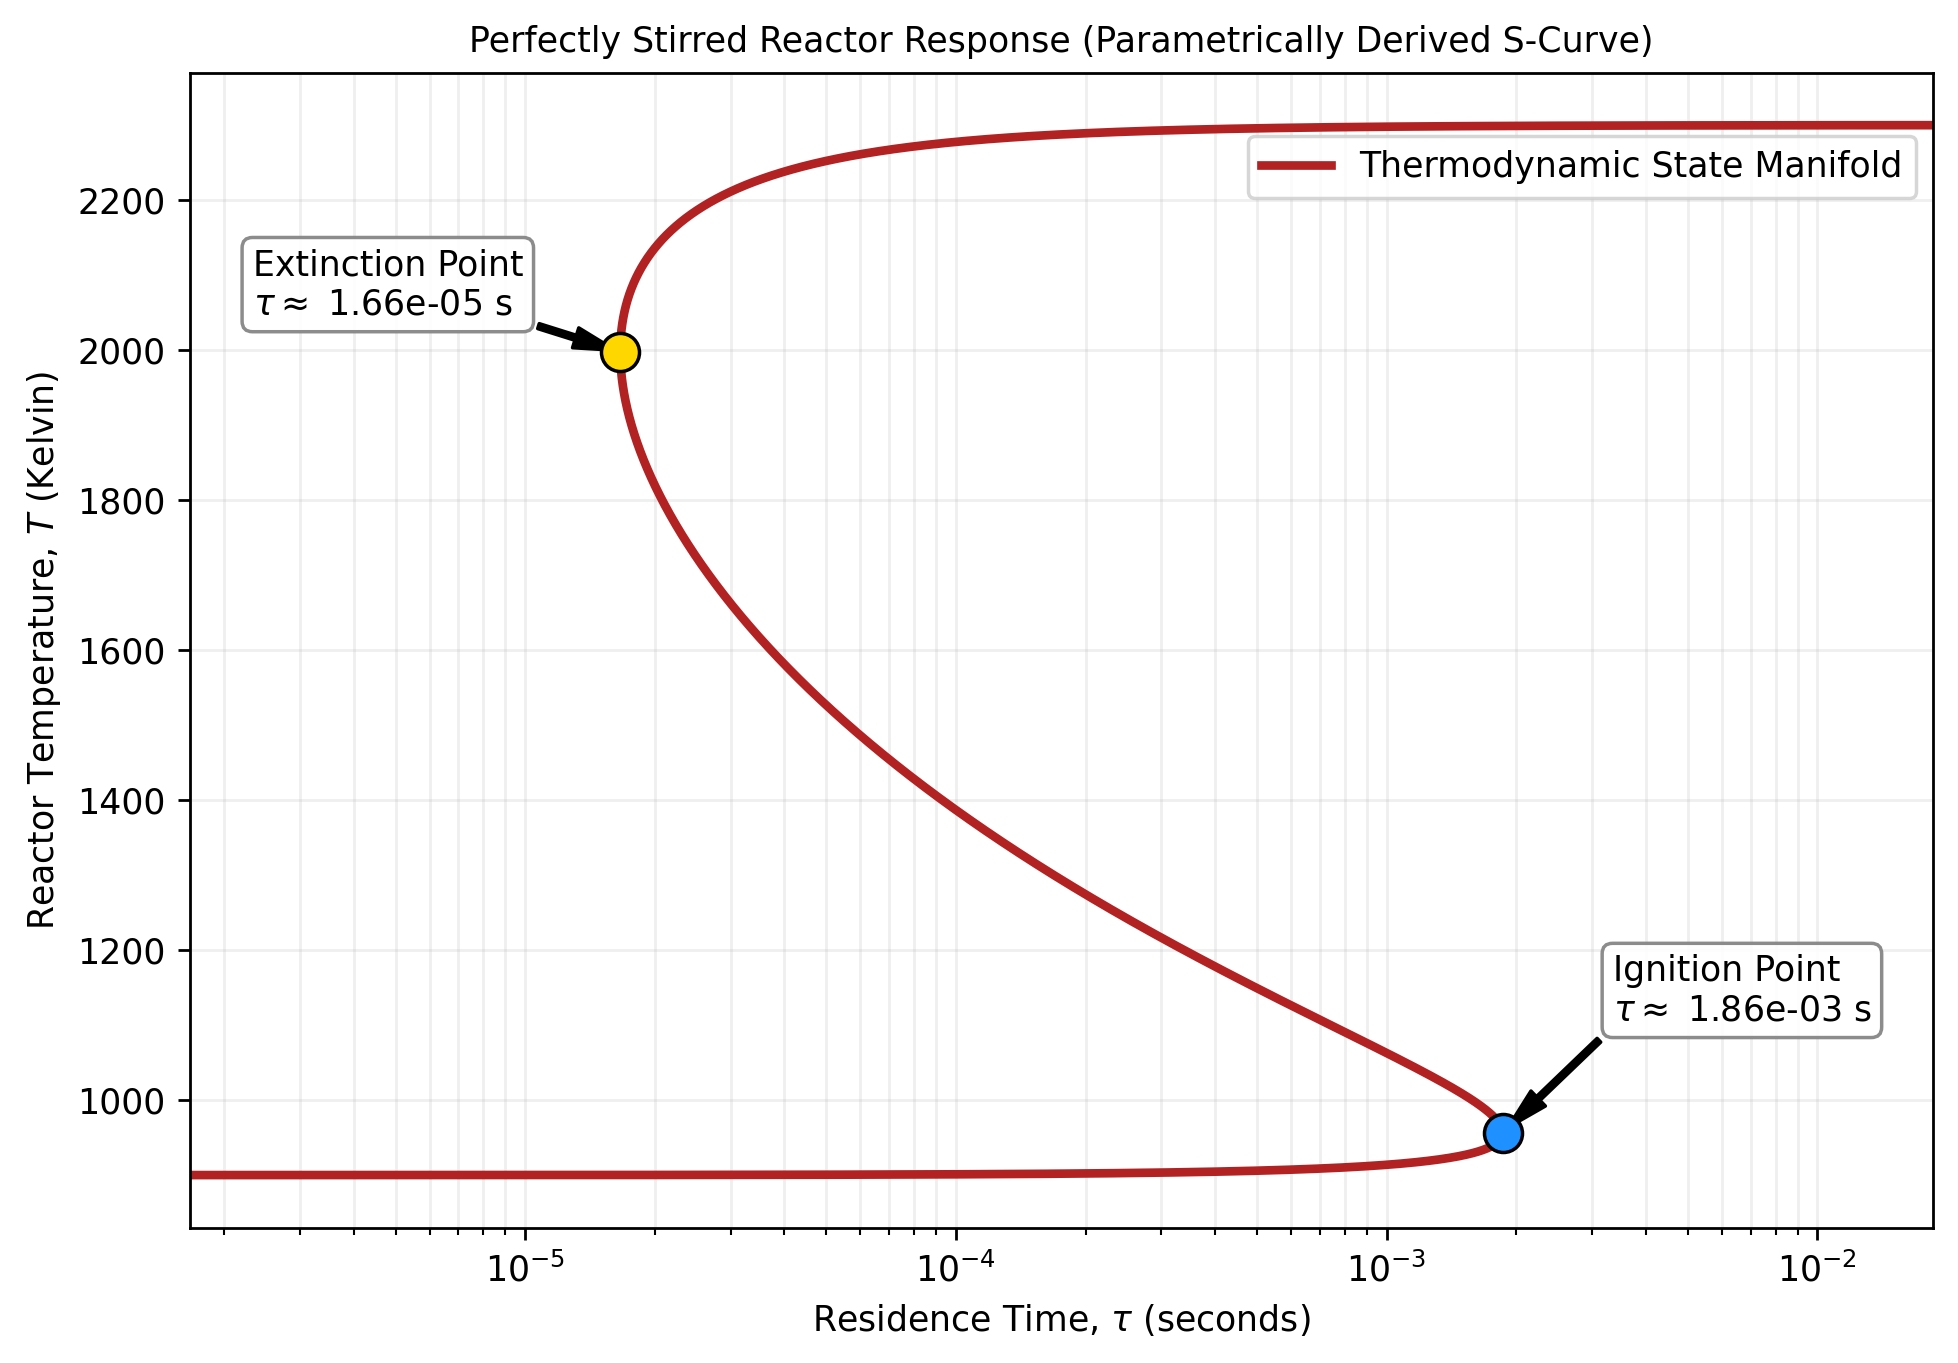

In [11]:
!uv pip install cupy-cuda12x scipy matplotlib numpy

import cupy as cp
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Establish rendering parameters for local notebook display
matplotlib.rcParams['figure.dpi'] = 250
matplotlib.rcParams['axes.titlesize'] = 10

# ==========================================
# CONTROL KNOBS (Parameter Definitions)
# ==========================================
NUM_TEMPERATURE_POINTS = 50000   # Resolution of the thermodynamic state array
INLET_TEMPERATURE = 900.0        # Pre-heated unburned mixture boundary condition (Kelvin)
ADIABATIC_TEMPERATURE = 2300.0   # Maximum theoretical burning boundary (Kelvin)
ACTIVATION_ENERGY = 1.4e5        # Global chemical activation energy (Joules per mole)
UNIVERSAL_GAS = 8.314            # Ideal gas constant (Joules per mole Kelvin)
PRE_EXPONENTIAL = 1e9            # Arrhenius collision frequency factor (1 per second)
# ==========================================

def compute_parametric_s_curve(
    num_points: int,
    t_inlet: float,
    t_adiabatic: float
) -> tuple:
    """
    Computes the complete multi-valued Perfectly Stirred Reactor (PSR) S-curve
    using a direct analytical inversion upon a Graphics Processing Unit (GPU) array.
    """
    print(f"Allocating {num_points} continuous thermodynamic states on the GPU...")

    # Generate a linear array of temperatures bounded safely away from the absolute limits
    t_array = cp.linspace(t_inlet + 1e-2, t_adiabatic - 1e-2, num_points, dtype=cp.float64)

    print("Executing analytical inversion to resolve parametric residence times...")

    # Direct computation of the residence time (tau) for every temperature state
    numerator = t_array - t_inlet
    exponential_term = cp.exp(-ACTIVATION_ENERGY / (UNIVERSAL_GAS * t_array))
    denominator = PRE_EXPONENTIAL * exponential_term * (t_adiabatic - t_array)

    tau_array = numerator / denominator

    # Transfer the perfectly continuous arrays to the Central Processing Unit (CPU)
    tau_cpu = tau_array.get()
    t_cpu = t_array.get()

    # Identify the precise Extinction Point
    # (The local minimum of residence time along the upper burning branch)
    upper_branch_mask = t_cpu > (t_inlet + 0.6 * (t_adiabatic - t_inlet))
    extinction_idx = np.argmin(tau_cpu[upper_branch_mask])
    extinction_tau = tau_cpu[upper_branch_mask][extinction_idx]
    extinction_temp = t_cpu[upper_branch_mask][extinction_idx]

    # Identify the precise Ignition Point
    # (The local maximum of residence time along the lower cold branch)
    lower_branch_mask = t_cpu < (t_inlet + 0.4 * (t_adiabatic - t_inlet))
    ignition_idx = np.argmax(tau_cpu[lower_branch_mask])
    ignition_tau = tau_cpu[lower_branch_mask][ignition_idx]
    ignition_temp = t_cpu[lower_branch_mask][ignition_idx]

    return tau_cpu, t_cpu, extinction_tau, extinction_temp, ignition_tau, ignition_temp

if __name__ == "__main__":
    # Execute the stabilized parametric generation
    tau_vals, t_vals, ext_tau, ext_temp, ign_tau, ign_temp = compute_parametric_s_curve(
        num_points=NUM_TEMPERATURE_POINTS,
        t_inlet=INLET_TEMPERATURE,
        t_adiabatic=ADIABATIC_TEMPERATURE
    )

    # Construct the scientific visualization
    plt.figure(figsize=(9, 6))

    # Plot the perfectly smooth, continuous S-curve manifold
    plt.semilogx(tau_vals, t_vals, color='firebrick', linewidth=2.5, label='Thermodynamic State Manifold')

    # Highlight the Extinction Point coordinate
    plt.scatter(ext_tau, ext_temp, color='gold', edgecolor='black', s=120, zorder=5)
    plt.annotate(
        f'Extinction Point\n$\\tau \\approx$ {ext_tau:.2e} s',
        xy=(ext_tau, ext_temp),
        xytext=(ext_tau * 0.14, ext_temp + 50),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

    # Highlight the Ignition Point coordinate
    plt.scatter(ign_tau, ign_temp, color='dodgerblue', edgecolor='black', s=120, zorder=5)
    plt.annotate(
        f'Ignition Point\n$\\tau \\approx$ {ign_tau:.2e} s',
        xy=(ign_tau, ign_temp),
        xytext=(ign_tau * 1.8, ign_temp + 150),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

    # Apply relevant labelings
    plt.title('Perfectly Stirred Reactor Response (Parametrically Derived S-Curve)')
    plt.xlabel('Residence Time, $\\tau$ (seconds)')
    plt.ylabel('Reactor Temperature, $T$ (Kelvin)')

    # Dynamically scale the x-axis to perfectly frame the Ignition and Extinction extrema
    plt.xlim(ext_tau * 0.1, ign_tau * 10.0)

    plt.grid(True, which="both", ls="-", alpha=0.2)

    # MODIFICATION: Explicitly shifted the legend downward by approximately 16 points
    plt.legend(loc='upper right', bbox_to_anchor=(1.0, 0.96))

    # Render explicitly to the Colab interface
    plt.show()